In [60]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

## Load Dataset

In [ ]:
df = pd.read_csv("../data/Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv")

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Rows    : 8173
Columns : 46


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,start_datetime,end_datetime,status,authenticated,modified_datetime,map_file,direction,description,veh_type,veh_no,corridor,priority,cargo_material,reason_breakdown,age_of_truck,created_date,route_path,client_id,created_by_id,last_modified_by_id,assigned_to_police_id,citizen_accident_id,comment,police_station,meta_data,kgid,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,2024-03-07 17:01:48.111+00,NaN,closed,yes,2024-03-07 19:35:47.871698+00,NaN,NaN,s m circle in coming man track,lcv,FKN00GL0000,Tumkur Road,High,NaN,NaN,NaN,2024-03-07 17:03:51.164032+00,NaN,1,FKUSR00000,FKUSR00001,NaN,NaN,NaN,Peenya,NaN,FKKG000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,2024-01-30 04:07:24.173+00,NaN,resolved,yes,2024-01-30 04:17:46.828979+00,NaN,NaN,Starting problem,heavy_vehicle,FKN00GL0001,ORR East 1,High,NaN,NaN,NaN,2024-01-30 04:08:22.954979+00,NaN,1,FKUSR00002,FKUSR00001,NaN,NaN,NaN,HSR Layout,NaN,FKKG000001,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,2023-11-11 06:18:03.343+00,NaN,closed,yes,2024-01-30 04:56:03.282003+00,NaN,NaN,ಊರ್ವಶಿ ಜಂಕ್ಷನ್ ನಲ್ಲಿ ಒಳಚರಂಡಿ ಚೇಂಬರ್ ಗೆ ಹೊಸದಾಗಿ...,NaN,NaN,Non-corridor,Low,NaN,NaN,NaN,2023-11-11 06:20:00.989398+00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,2024-03-07 17:56:55.061+00,NaN,closed,yes,2024-03-14 07:42:05.55005+00,NaN,NaN,tree fall,NaN,NaN,Non-corridor,Low,NaN,NaN,NaN,2024-03-07 17:58:56.696892+00,NaN,1,FKUSR00004,FKUSR00001,NaN,NaN,NaN,Sadashivanagar,NaN,FKKG000003,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,2024-01-30 04:56:32.348+00,NaN,closed,yes,2024-01-30 05:35:17.33908+00,NaN,NaN,[LOCATION] ಪೈಪ್ [PERSON] ವಾಹನ ಆಫ್ ಆಗಿರುತ್ತದೆ ಸರ್,private_bus,FKN00GL0002,Non-corridor,Low,NaN,NaN,NaN,2024-01-30 04:58:55.937662+00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


## Dataset Overview

Understanding all available fields before analysis.

In [62]:
meta = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str),
    "Missing": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2),
    "Unique Values": df.nunique()
})

meta.sort_values(
    "Missing %",
    ascending=False
)

,Column,Dtype,Missing,Missing %,Unique Values
comment,comment,float64,8173,100.00,0
map_file,map_file,float64,8173,100.00,0
meta_data,meta_data,float64,8173,100.00,0
direction,direction,str,8130,99.47,8
resolved_at_address,resolved_at_address,str,8099,99.09,58
resolved_at_latitude,resolved_at_latitude,float64,8099,99.09,74
resolved_by_id,resolved_by_id,str,8099,99.09,42
resolved_datetime,resolved_datetime,str,8099,99.09,74
resolved_at_longitude,resolved_at_longitude,float64,8099,99.09,74
assigned_to_police_id,assigned_to_police_id,str,8045,98.43,62


## Data Types Distribution

In [63]:
meta["Dtype"].value_counts()

Dtype
str        34
float64    10
bool        1
int64       1
Name: count, dtype: int64

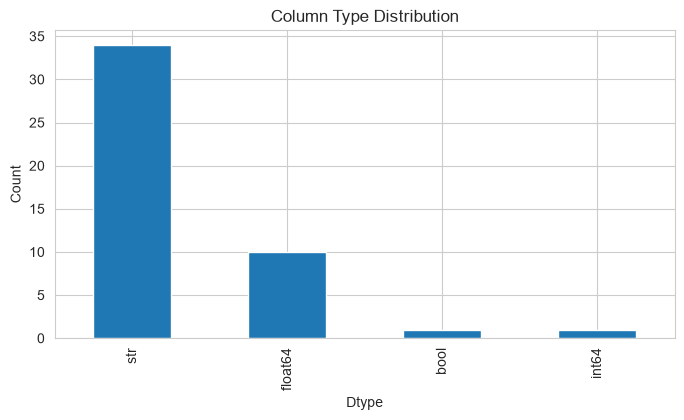

In [64]:
plt.figure(figsize=(8,4))

meta["Dtype"].value_counts().plot(
    kind="bar"
)

plt.title("Column Type Distribution")
plt.ylabel("Count")
plt.show()

## Missing Value Analysis

In [65]:
missing = (
    meta[
        meta["Missing"] > 0
    ]
    .sort_values(
        "Missing %",
        ascending=False
    )
)

missing

,Column,Dtype,Missing,Missing %,Unique Values
map_file,map_file,float64,8173,100.00,0
meta_data,meta_data,float64,8173,100.00,0
comment,comment,float64,8173,100.00,0
direction,direction,str,8130,99.47,8
resolved_at_longitude,resolved_at_longitude,float64,8099,99.09,74
resolved_at_latitude,resolved_at_latitude,float64,8099,99.09,74
resolved_at_address,resolved_at_address,str,8099,99.09,58
resolved_datetime,resolved_datetime,str,8099,99.09,74
resolved_by_id,resolved_by_id,str,8099,99.09,42
citizen_accident_id,citizen_accident_id,str,8045,98.43,77


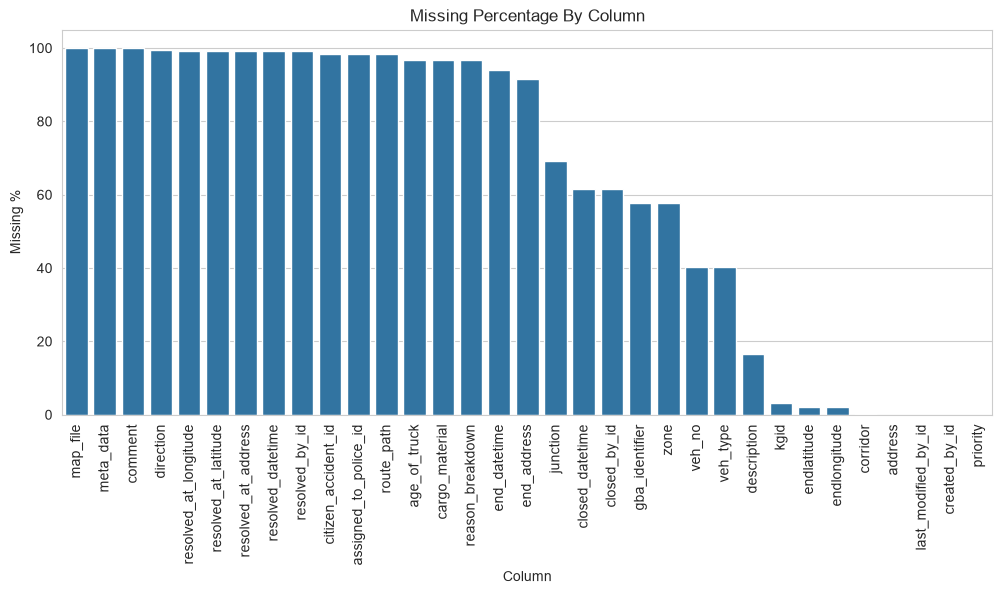

In [66]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=missing,
    x="Column",
    y="Missing %"
)

plt.xticks(rotation=90)
plt.title("Missing Percentage By Column")
plt.show()

# Phase 2

In [67]:
core_cols = [
    "event_type",
    "event_cause",
    "status",
    "priority",
    "police_station"
]

df[core_cols].head()

,event_type,event_cause,status,priority,police_station
0,unplanned,vehicle_breakdown,closed,High,Peenya
1,unplanned,vehicle_breakdown,resolved,High,HSR Layout
2,unplanned,others,closed,Low,Wilson Garden
3,unplanned,tree_fall,closed,Low,Sadashivanagar
4,unplanned,vehicle_breakdown,closed,Low,Wilson Garden


In [68]:
event_type_counts = (
    df["event_type"]
    .value_counts(dropna=False)
)

event_type_counts

event_type
unplanned    7706
planned       467
Name: count, dtype: int64

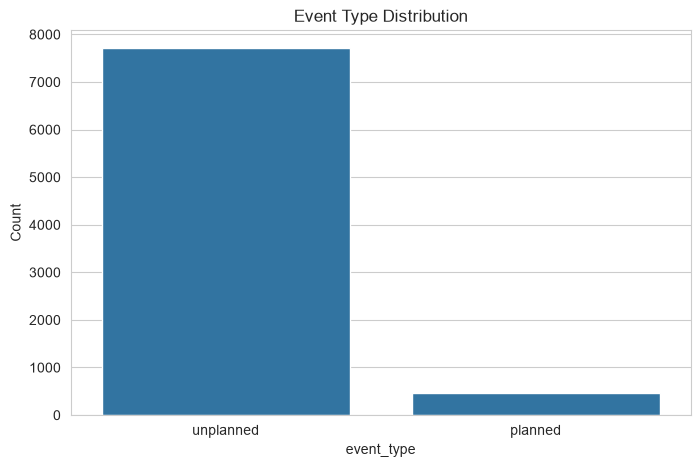

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=event_type_counts.index,
    y=event_type_counts.values
)

plt.title("Event Type Distribution")
plt.ylabel("Count")
plt.show()

In [70]:
cause_counts = (
    df["event_cause"]
    .value_counts()
)

cause_counts

event_cause
vehicle_breakdown       4896
others                   638
pot_holes                537
construction             480
water_logging            458
accident                 365
tree_fall                284
road_conditions          170
congestion               136
public_event              84
procession                72
vip_movement              20
protest                   15
Debris                    12
test_demo                  3
Fog / Low Visibility       2
debris                     1
Name: count, dtype: int64

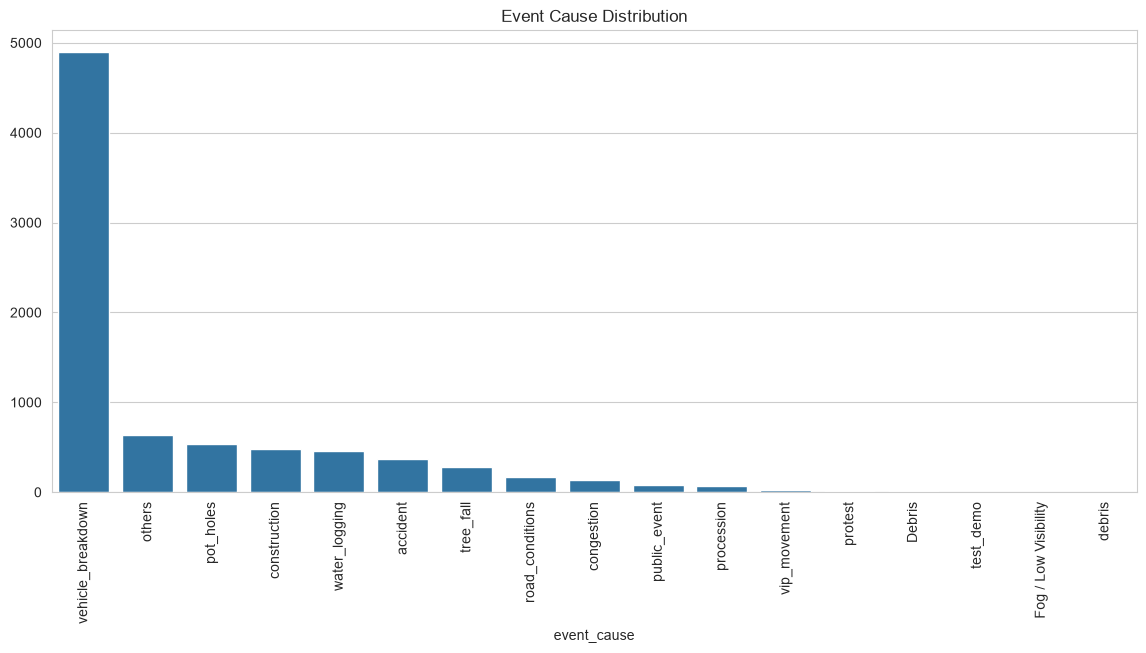

In [71]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=cause_counts.index,
    y=cause_counts.values
)

plt.xticks(rotation=90)
plt.title("Event Cause Distribution")
plt.show()

In [72]:
cause_pct = (
    cause_counts
    .reset_index()
)

cause_pct.columns = ["cause","count"]

cause_pct["pct"] = (
    cause_pct["count"] /
    cause_pct["count"].sum()
) * 100

cause_pct["cum_pct"] = (
    cause_pct["pct"]
    .cumsum()
)

cause_pct.head(20)

,cause,count,pct,cum_pct
0,vehicle_breakdown,4896,59.904564,59.904564
1,others,638,7.806191,67.710755
2,pot_holes,537,6.570415,74.281170
3,construction,480,5.872996,80.154166
4,water_logging,458,5.603817,85.757984
5,accident,365,4.465924,90.223908
6,tree_fall,284,3.474856,93.698764
7,road_conditions,170,2.080020,95.778784
8,congestion,136,1.664016,97.442799
9,public_event,84,1.027774,98.470574


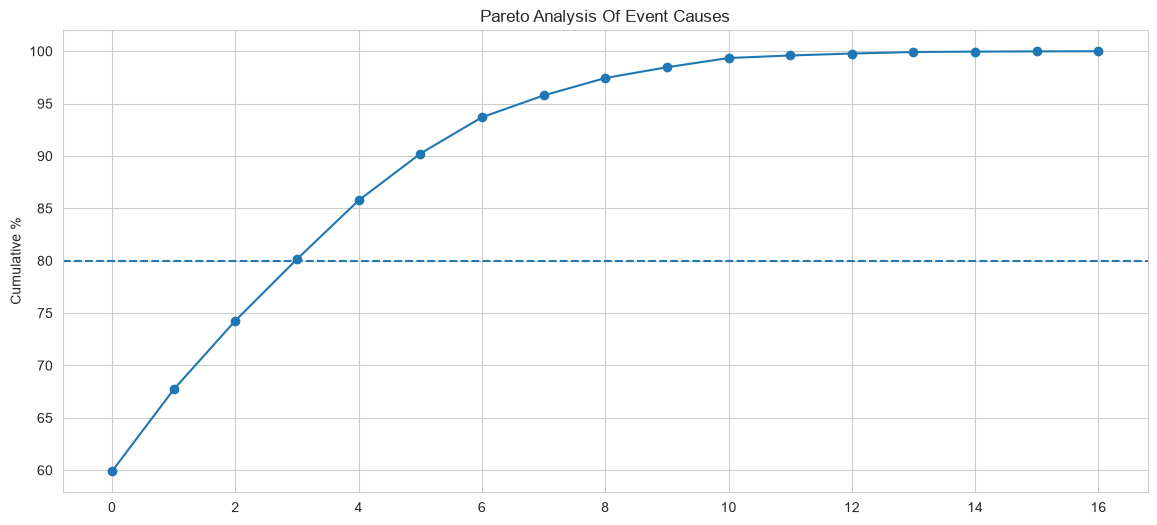

In [73]:
plt.figure(figsize=(14,6))

plt.plot(
    cause_pct["cum_pct"].values,
    marker="o"
)

plt.axhline(
    80,
    linestyle="--"
)

plt.title("Pareto Analysis Of Event Causes")
plt.ylabel("Cumulative %")
plt.show()

In [74]:
priority_counts = (
    df["priority"]
    .value_counts(dropna=False)
)

priority_counts

priority
High    5030
Low     3141
NaN        2
Name: count, dtype: int64

In [75]:
status_counts = (
    df["status"]
    .value_counts()
)

status_counts

status
closed      7095
active      1007
resolved      71
Name: count, dtype: int64

In [76]:
station_counts = (
    df["police_station"]
    .value_counts()
)

station_counts.head(20)

police_station
Yelahanka            377
HAL Old Airport      361
Sadashivanagar       302
Byatarayanapura      297
Halasuru Gate        297
Yeshwanthpura        280
Hennuru              276
Kodigehalli          272
Banaswadi            245
K.R. Pura            228
Kamakshipalya        224
No Police Station    219
Cubbon Park          212
Jalahalli            197
Chamarajpet          192
High ground          185
Madiwala             184
Whitefield           181
Peenya               178
Jayanagara           178
Name: count, dtype: int64

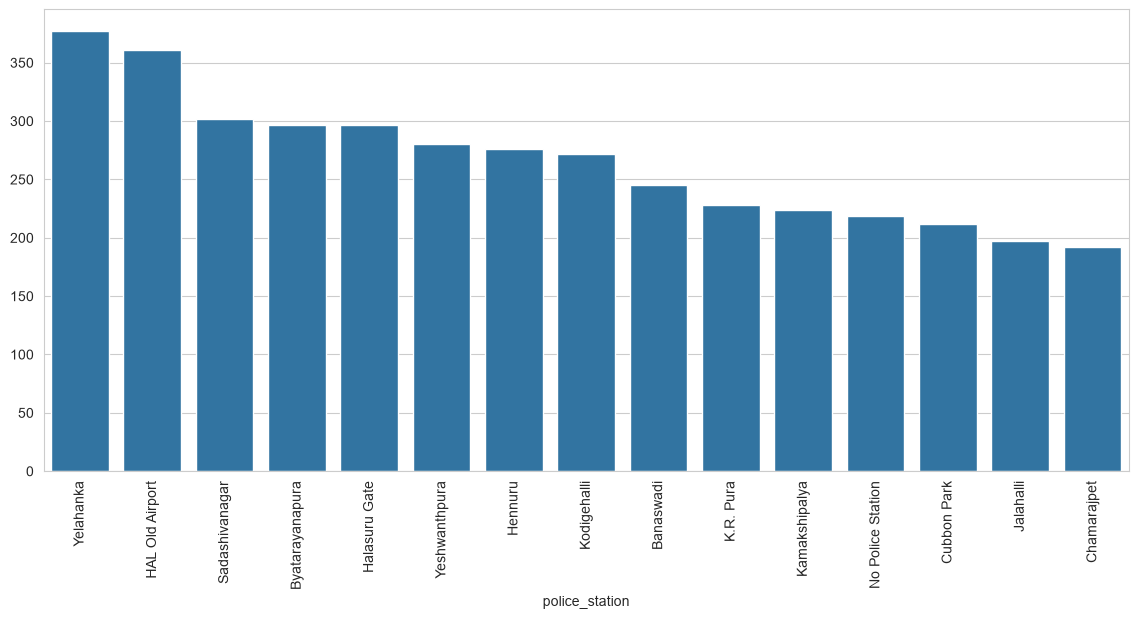

In [77]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=station_counts.head(15).index,
    y=station_counts.head(15).values
)

plt.xticks(rotation=90)
plt.show()

# EDA 03 - Operational Burden Analysis

In [78]:
cause_priority = pd.crosstab(
    df["event_cause"],
    df["priority"]
)

cause_priority

priority,High,Low
event_cause,,
Debris,8,4
Fog / Low Visibility,1,1
accident,168,197
congestion,94,42
construction,302,178
debris,1,0
others,380,258
pot_holes,299,238
procession,23,49


In [79]:
cause_priority_pct = pd.crosstab(
    df["event_cause"],
    df["priority"],
    normalize="index"
) * 100

cause_priority_pct.round(2)

priority,High,Low
event_cause,,
Debris,66.67,33.33
Fog / Low Visibility,50.00,50.00
accident,46.03,53.97
congestion,69.12,30.88
construction,62.92,37.08
debris,100.00,0.00
others,59.56,40.44
pot_holes,55.68,44.32
procession,31.94,68.06


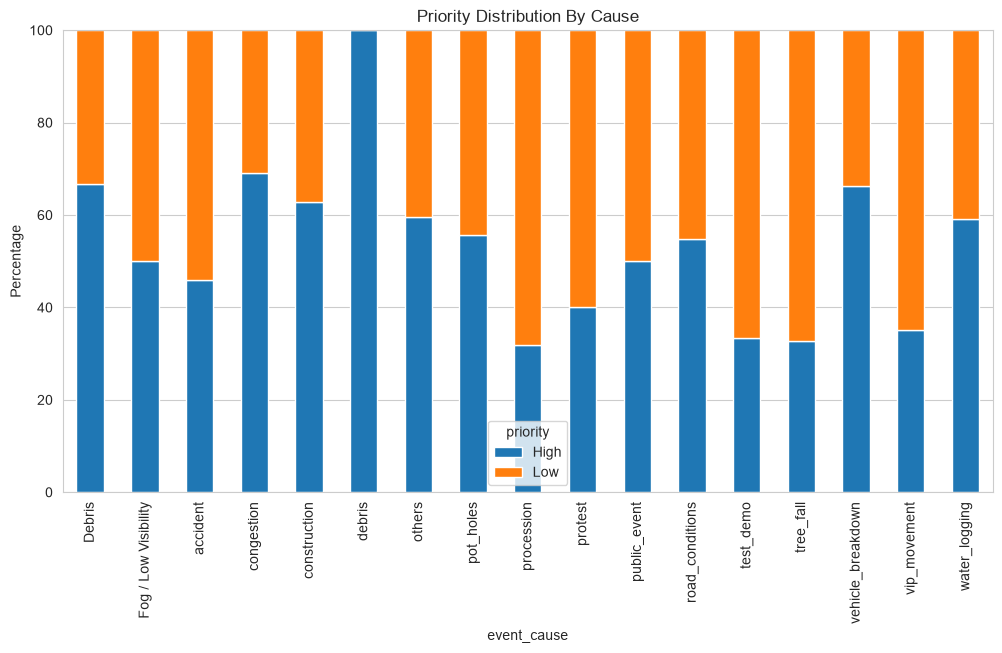

In [80]:
cause_priority_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.ylabel("Percentage")
plt.title("Priority Distribution By Cause")
plt.show()

In [81]:
cause_status = pd.crosstab(
    df["event_cause"],
    df["status"]
)

cause_status

status,active,closed,resolved
event_cause,,,
Debris,8,4,0
Fog / Low Visibility,0,2,0
accident,0,361,4
congestion,0,136,0
construction,73,407,0
debris,1,0,0
others,195,438,5
pot_holes,358,177,2
procession,0,72,0


In [82]:
cause_status_pct = pd.crosstab(
    df["event_cause"],
    df["status"],
    normalize="index"
) * 100

cause_status_pct

status,active,closed,resolved
event_cause,,,
Debris,66.666667,33.333333,0.000000
Fog / Low Visibility,0.000000,100.000000,0.000000
accident,0.000000,98.904110,1.095890
congestion,0.000000,100.000000,0.000000
construction,15.208333,84.791667,0.000000
debris,100.000000,0.000000,0.000000
others,30.564263,68.652038,0.783699
pot_holes,66.666667,32.960894,0.372439
procession,0.000000,100.000000,0.000000


In [83]:
station_cause = pd.crosstab(
    df["police_station"],
    df["event_cause"]
)

station_cause.head()

event_cause,Debris,Fog / Low Visibility,accident,congestion,construction,debris,others,pot_holes,procession,protest,public_event,road_conditions,test_demo,tree_fall,vehicle_breakdown,vip_movement,water_logging
police_station,,,,,,,,,,,,,,,,,
Adugodi,0,0,1,1,4,0,7,31,2,0,1,6,0,5,54,0,8
Ashok Nagar,0,0,4,0,11,0,23,15,1,1,3,3,0,7,83,0,20
Banashankari,4,0,1,0,3,0,6,1,0,0,0,9,0,5,73,0,0
Banaswadi,0,0,11,4,21,0,13,5,0,0,2,0,0,13,168,0,8
Basavanagudi,1,0,4,0,2,0,0,9,0,0,0,0,0,11,13,0,7


In [84]:
top_stations = (
    df["police_station"]
    .value_counts()
    .head(10)
    .index
)

station_cause = station_cause.loc[top_stations]

station_cause

event_cause,Debris,Fog / Low Visibility,accident,congestion,construction,debris,others,pot_holes,procession,protest,public_event,road_conditions,test_demo,tree_fall,vehicle_breakdown,vip_movement,water_logging
police_station,,,,,,,,,,,,,,,,,
Yelahanka,0,0,32,0,21,0,25,10,7,0,2,7,0,4,251,0,18
HAL Old Airport,0,0,3,1,136,0,20,27,1,1,5,4,0,1,136,1,25
Sadashivanagar,0,0,7,2,3,0,26,10,0,0,1,7,0,22,216,0,8
Byatarayanapura,0,0,7,2,1,0,35,3,1,0,0,3,0,0,238,0,7
Halasuru Gate,0,0,6,2,4,0,16,4,1,2,1,6,0,4,234,1,16
Yeshwanthpura,0,0,6,1,5,0,11,8,1,1,2,0,0,11,228,0,6
Hennuru,0,0,9,32,65,0,32,6,4,1,2,12,0,0,104,1,8
Kodigehalli,0,1,12,38,24,0,19,5,2,0,0,5,0,17,139,0,10
Banaswadi,0,0,11,4,21,0,13,5,0,0,2,0,0,13,168,0,8


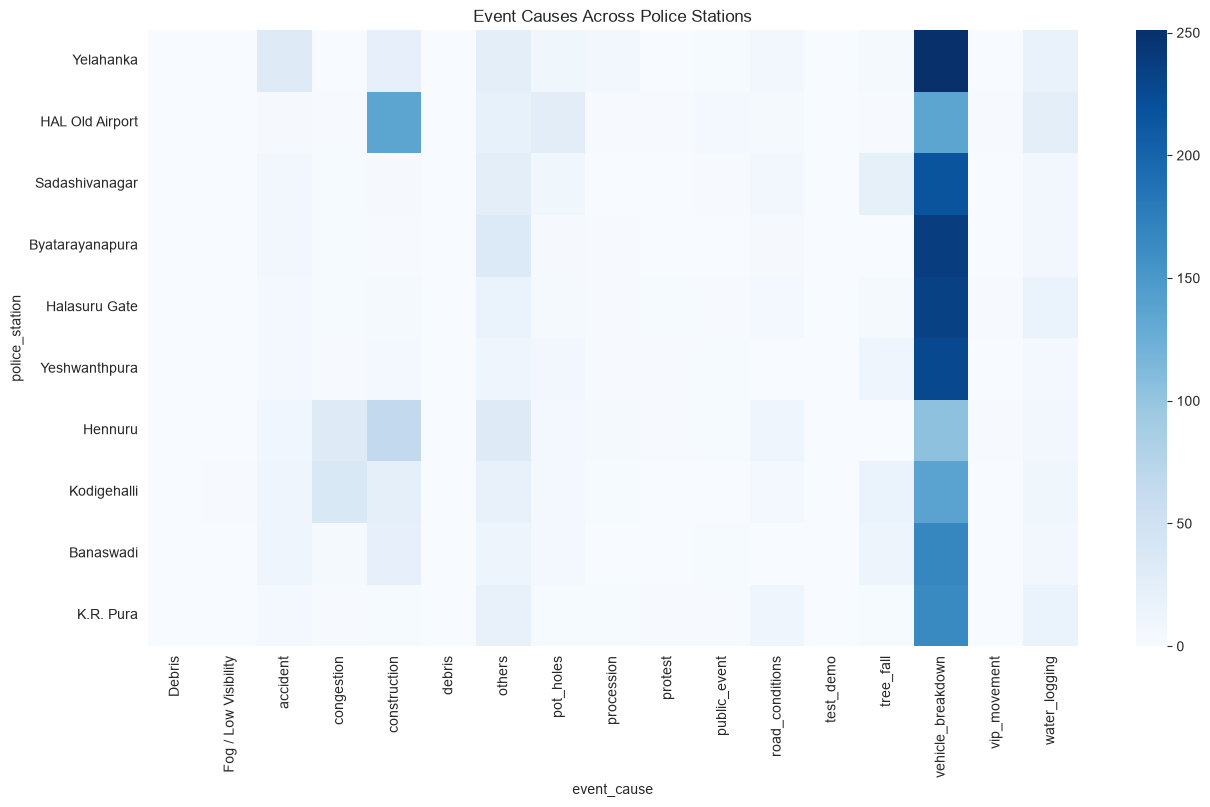

In [85]:
plt.figure(figsize=(15,8))

sns.heatmap(
    station_cause,
    cmap="Blues"
)

plt.title(
    "Event Causes Across Police Stations"
)

plt.show()

In [86]:
pd.crosstab(
    df["event_cause"],
    df["requires_road_closure"]
)

requires_road_closure,False,True
event_cause,,
Debris,11,1
Fog / Low Visibility,2,0
accident,354,11
congestion,130,6
construction,353,127
debris,0,1
others,583,55
pot_holes,524,13
procession,53,19


In [87]:
closure_pct = pd.crosstab(
    df["event_cause"],
    df["requires_road_closure"],
    normalize="index"
) * 100

closure_pct.round(2)

requires_road_closure,False,True
event_cause,,
Debris,91.67,8.33
Fog / Low Visibility,100.00,0.00
accident,96.99,3.01
congestion,95.59,4.41
construction,73.54,26.46
debris,0.00,100.00
others,91.38,8.62
pot_holes,97.58,2.42
procession,73.61,26.39


In [88]:
priority_station = pd.crosstab(
    df["police_station"],
    df["priority"]
)

priority_station.head()

priority,High,Low
police_station,,
Adugodi,72,48
Ashok Nagar,134,37
Banashankari,69,33
Banaswadi,195,50
Basavanagudi,0,47


In [89]:
priority_station_pct = pd.crosstab(
    df["police_station"],
    df["priority"],
    normalize="index"
) * 100

priority_station_pct

priority,High,Low
police_station,,
Adugodi,60.000000,40.000000
Ashok Nagar,78.362573,21.637427
Banashankari,67.647059,32.352941
Banaswadi,79.591837,20.408163
Basavanagudi,0.000000,100.000000
Bellandur,66.326531,33.673469
Byatarayanapura,92.567568,7.432432
Chamarajpet,65.104167,34.895833
Chikkabanavara,54.237288,45.762712


In [90]:
station_events = (
    df.groupby("police_station")
      .size()
      .sort_values(ascending=False)
)

station_events.head(20)

police_station
Yelahanka            377
HAL Old Airport      361
Sadashivanagar       302
Byatarayanapura      297
Halasuru Gate        297
Yeshwanthpura        280
Hennuru              276
Kodigehalli          272
Banaswadi            245
K.R. Pura            228
Kamakshipalya        224
No Police Station    219
Cubbon Park          212
Jalahalli            197
Chamarajpet          192
High ground          185
Madiwala             184
Whitefield           181
Jayanagara           178
Peenya               178
dtype: int64

In [91]:
station_cause = pd.crosstab(
    df["police_station"],
    df["event_cause"]
)

station_cause

event_cause,Debris,Fog / Low Visibility,accident,congestion,construction,debris,others,pot_holes,procession,protest,public_event,road_conditions,test_demo,tree_fall,vehicle_breakdown,vip_movement,water_logging
police_station,,,,,,,,,,,,,,,,,
Adugodi,0,0,1,1,4,0,7,31,2,0,1,6,0,5,54,0,8
Ashok Nagar,0,0,4,0,11,0,23,15,1,1,3,3,0,7,83,0,20
Banashankari,4,0,1,0,3,0,6,1,0,0,0,9,0,5,73,0,0
Banaswadi,0,0,11,4,21,0,13,5,0,0,2,0,0,13,168,0,8
Basavanagudi,1,0,4,0,2,0,0,9,0,0,0,0,0,11,13,0,7
Bellandur,0,0,7,0,5,0,7,0,3,0,5,0,0,2,64,1,4
Byatarayanapura,0,0,7,2,1,0,35,3,1,0,0,3,0,0,238,0,7
Chamarajpet,0,0,8,2,4,0,19,8,2,0,2,2,0,6,119,0,20
Chikkabanavara,0,1,4,1,3,0,9,2,0,0,0,0,0,0,96,0,2


In [92]:
top_stations = (
    df["police_station"]
    .value_counts()
    .head(15)
    .index
)

heatmap_data = station_cause.loc[top_stations]

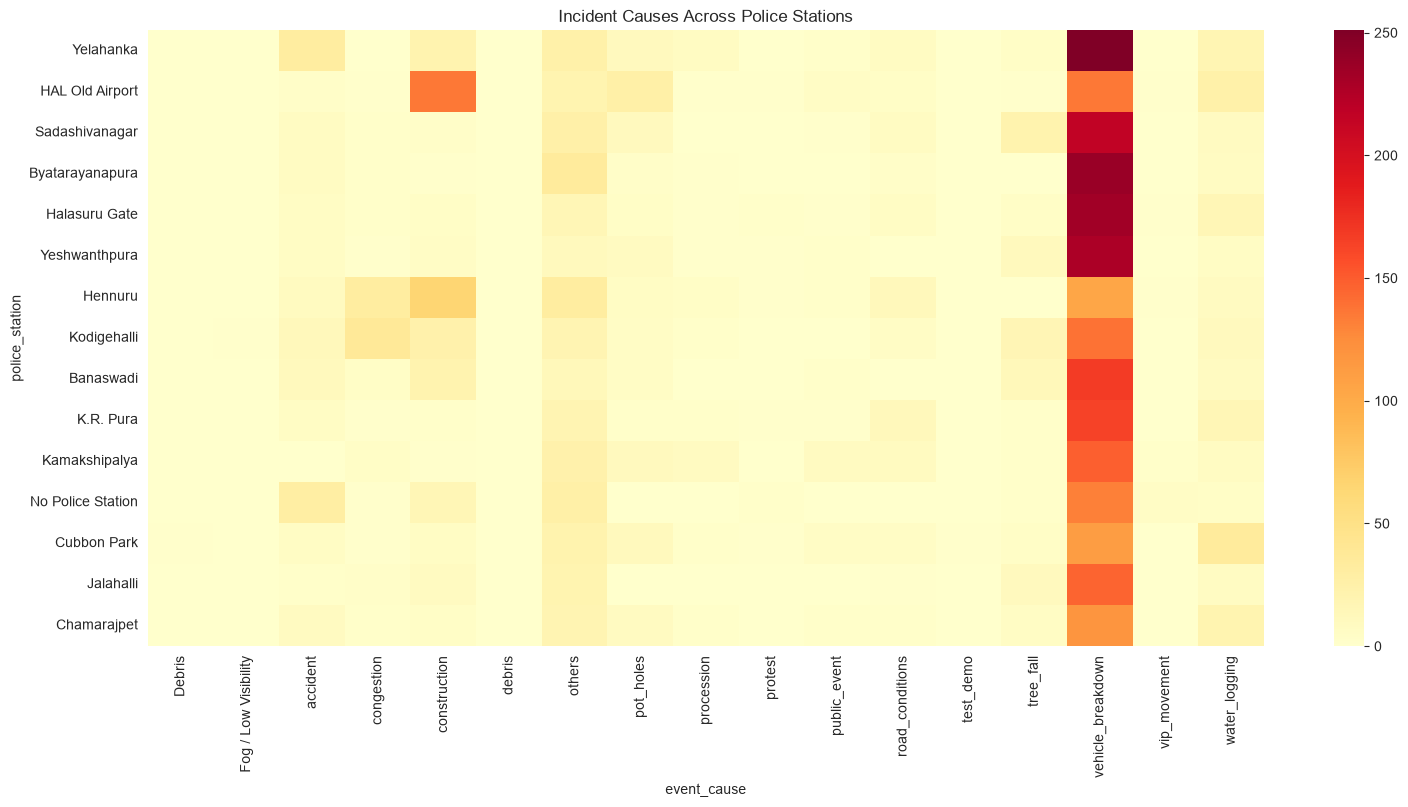

In [93]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd"
)

plt.title(
    "Incident Causes Across Police Stations"
)

plt.show()

In [94]:
breakdown_df = df[
    df["event_cause"] == "vehicle_breakdown"
]

breakdown_station = (
    breakdown_df["police_station"]
    .value_counts()
    .head(20)
)

breakdown_station

police_station
Yelahanka            251
Byatarayanapura      238
Halasuru Gate        234
Yeshwanthpura        228
Sadashivanagar       216
Banaswadi            168
K.R. Pura            164
Kamakshipalya        149
Jalahalli            146
Kodigehalli          139
Peenya               137
HAL Old Airport      136
No Police Station    132
High ground          127
Chamarajpet          119
Cubbon Park          112
Hennuru              104
Magadi Road          100
Chikkabanavara        96
Jnanabharathi         94
Name: count, dtype: int64

In [95]:
infra_causes = [
    "pot_holes",
    "water_logging",
    "road_conditions",
    "tree_fall",
    "construction"
]

In [96]:
infra = df[
    df["event_cause"].isin(infra_causes)
]

In [97]:
infra_station = (
    infra["police_station"]
    .value_counts()
)

infra_station.head(20)

police_station
HAL Old Airport           193
Hennuru                    91
Madiwala                   87
Hulimavu                   79
J.P. Nagar                 70
Jayanagara                 61
Cubbon Park                61
Kodigehalli                61
Yelahanka                  60
Whitefield                 56
Ashok Nagar                56
Adugodi                    54
Sadashivanagar             50
Banaswadi                  47
High ground                46
Pulikeshinagar(F.Town)     41
Chamarajpet                40
Jeevanbheemanagar          38
Mahadevapura               36
Halasur                    36
Name: count, dtype: int64

In [98]:
active_df = df[
    df["status"] == "active"
]

In [99]:
active_station = (
    active_df["police_station"]
    .value_counts()
)

active_station.head(20)

police_station
Hulimavu             72
Madiwala             68
HAL Old Airport      55
J.P. Nagar           47
Hennuru              42
Adugodi              39
No Police Station    37
Jayanagara           35
Jeevanbheemanagar    33
Ashok Nagar          33
Cubbon Park          31
Banaswadi            31
Shivajinagar         30
Kodigehalli          27
HSR Layout           21
Sheshadripuram       20
High ground          19
R.T. Nagar           18
Mahadevapura         17
Whitefield           17
Name: count, dtype: int64

In [100]:
high_df = df[
    df["priority"] == "High"
]

In [101]:
high_station = (
    high_df["police_station"]
    .value_counts()
)

high_station.head(20)

police_station
HAL Old Airport      323
Yelahanka            287
Byatarayanapura      274
Yeshwanthpura        254
Kodigehalli          237
Sadashivanagar       235
Halasuru Gate        214
Hennuru              201
Banaswadi            195
Kamakshipalya        185
Cubbon Park          163
Madiwala             153
Jalahalli            149
Ashok Nagar          134
Peenya               130
Hebbala              127
Chamarajpet          125
HSR Layout           113
Jeevanbheemanagar    111
Magadi Road          109
Name: count, dtype: int64

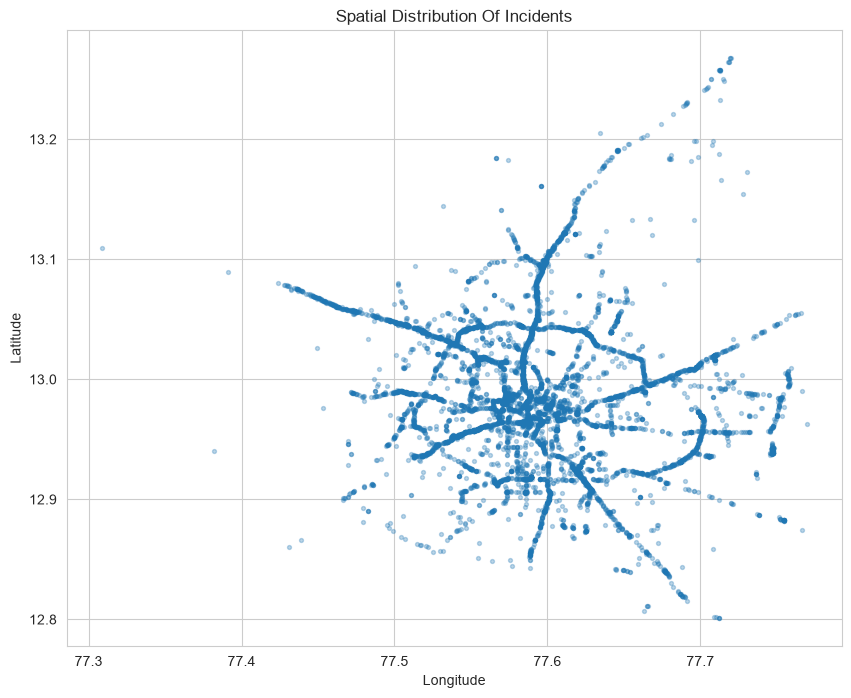

In [102]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.3,
    s=8
)

plt.title(
    "Spatial Distribution Of Incidents"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

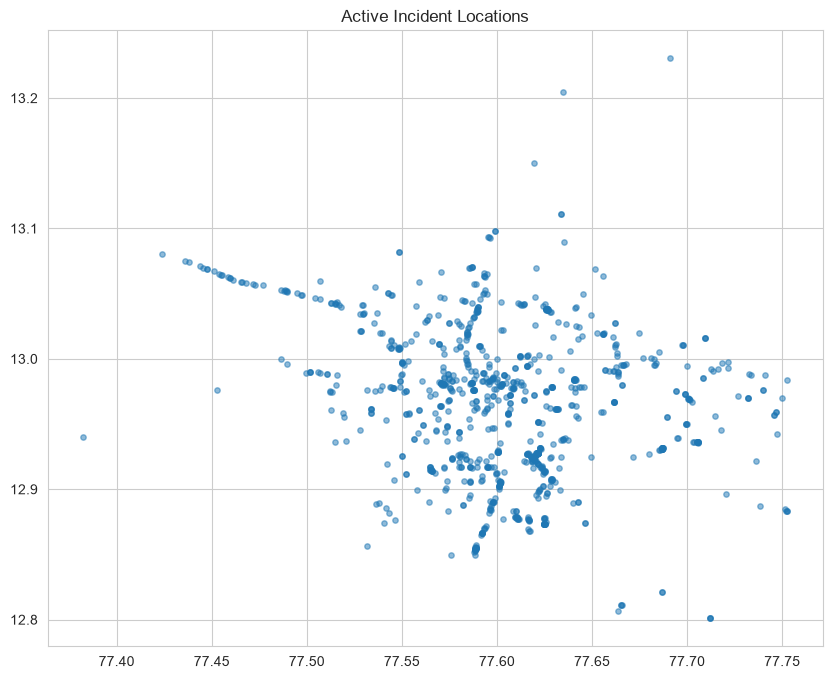

In [103]:
plt.figure(figsize=(10,8))

plt.scatter(
    active_df["longitude"],
    active_df["latitude"],
    alpha=0.5,
    s=15
)

plt.title(
    "Active Incident Locations"
)

plt.show()

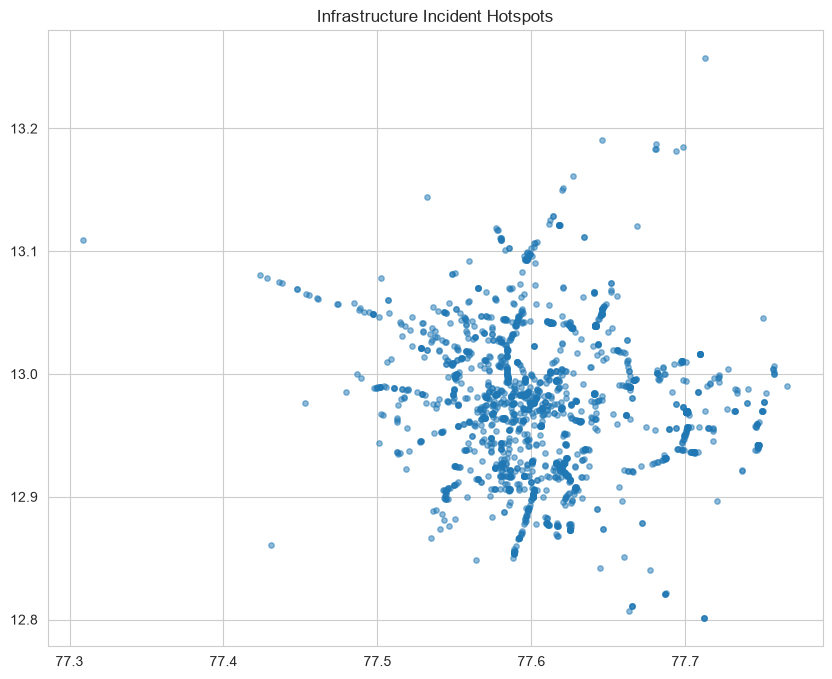

In [104]:
plt.figure(figsize=(10,8))

plt.scatter(
    infra["longitude"],
    infra["latitude"],
    alpha=0.5,
    s=15
)

plt.title(
    "Infrastructure Incident Hotspots"
)

plt.show()

In [105]:
junction_counts = (
    df["junction"]
    .dropna()
    .value_counts()
)

junction_counts.head(20)

junction
MekhriCircle                      64
AyyappaTempleJunc                 49
SatteliteBusStandJunc             43
YeshwanthpuraCircle               38
YelhankaCircle                    34
SilkBoardJunc                     33
toll gate mysore road             33
JalahalliCross(SM Circle)         32
Nagavara-ORR Junction             32
K R Circle                        31
KIMCO Junction                    31
VeerannapalyaJunction(BEL,HO)     30
TownhallJunction                  30
HesaraghattaJunction              30
Devasandra(k r puram)             30
KoramangalaWaterTankJunc          29
HebbalFlyoverJunc                 28
GokuldasImagesJunc                28
BagalurCrossJunc                  27
BigBazaarJunction(OldMadrasRd)    26
Name: count, dtype: int64